***
**Signal-Based Capacity and Saturation Analysis for LSA9**
***


**LSA9 Signal Green Time Parser**

In [1]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 1: LSA9 SIGNAL GREEN TIME PARSER
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA9_e31ef6a7-ced8-42fe-9ac2-fef01677d7de"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA9_green_time_summary.csv"
OUT_XLSX = OUT_DIR / "LSA9_green_time_summary.xlsx"

GREEN_STATE = 4

APPROACH_SIGNAL_MAP = {
    "West":       {"signal_group": "K1", "signal_id": 1},
    "South":      {"signal_group": "K4", "signal_id": 4},
    "East":       {"signal_group": "K3", "signal_id": 3},
    "North_East": {"signal_group": "K2", "signal_id": 2},
    "North_West": {"signal_group": "K2", "signal_id": 2},
}

SCENARIOS = {
    "weekday_morning": {"date": "2026-03-10", "start": "08:00:00", "end": "09:00:00"},
    "weekday_evening": {"date": "2026-03-23", "start": "16:00:00", "end": "17:00:00"},
    "weekend_morning": {"date": "2026-03-14", "start": "08:00:00", "end": "09:00:00"},
    "weekend_evening": {"date": "2026-03-22", "start": "16:00:00", "end": "17:00:00"},
}

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {item["id"]: item["sgState"] for item in value.get("sigState", [])}
            node_info = value.get("nodes", [{}])[0]

            for approach, info in APPROACH_SIGNAL_MAP.items():
                signal_id = info["signal_id"]

                if signal_id in sig_states:
                    sg_state = sig_states[signal_id]

                    rows.append({
                        "file": json_path.name,
                        "timestamp_local": timestamp_local,
                        "date": str(timestamp_local.date()),
                        "time": timestamp_local.time(),
                        "approach": approach,
                        "signal_group": info["signal_group"],
                        "signal_id": signal_id,
                        "sg_state": sg_state,
                        "is_green": sg_state == GREEN_STATE,
                        "program": node_info.get("program"),
                        "stage": node_info.get("stage"),
                        "cycCnt": node_info.get("cycCnt"),
                        "stgCnt": node_info.get("stgCnt"),
                        "stgTran": node_info.get("stgTran"),
                    })

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_signal = pd.DataFrame(rows)
print("Parsed signal rows:", len(df_signal))

if df_signal.empty:
    raise ValueError("No signal data parsed. Check SIGNAL_DIR.")

selected_parts = []

for scenario_name, scenario in SCENARIOS.items():
    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    temp = df_signal[
        (df_signal["date"] == scenario["date"]) &
        (df_signal["time"] >= start_t) &
        (df_signal["time"] < end_t)
    ].copy()

    temp["scenario"] = scenario_name
    temp["window_start"] = scenario["start"]
    temp["window_end"] = scenario["end"]

    selected_parts.append(temp)

df_selected_signal = pd.concat(selected_parts, ignore_index=True)

print("Selected signal rows:", len(df_selected_signal))

if df_selected_signal.empty:
    raise ValueError("No signal data found for selected representative scenarios.")

green_summary = (
    df_selected_signal
    .groupby([
        "scenario", "date", "window_start", "window_end",
        "approach", "signal_group", "signal_id"
    ])
    .agg(
        observed_seconds=("sg_state", "count"),
        green_seconds=("is_green", "sum"),
        cycle_count=("cycCnt", "nunique")
    )
    .reset_index()
)

green_summary["green_minutes"] = green_summary["green_seconds"] / 60
green_summary["green_share_percent"] = green_summary["green_seconds"] / green_summary["observed_seconds"] * 100
green_summary["avg_cycle_time_s"] = green_summary["observed_seconds"] / green_summary["cycle_count"]
green_summary["avg_green_per_cycle_s"] = green_summary["green_seconds"] / green_summary["cycle_count"]

green_summary = green_summary.sort_values(["scenario", "approach"])

green_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

df_selected_signal_excel = df_selected_signal.copy()
df_selected_signal_excel["timestamp_local"] = df_selected_signal_excel["timestamp_local"].astype(str)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    green_summary.to_excel(writer, sheet_name="Green_Time_Summary", index=False)
    df_selected_signal_excel.to_excel(writer, sheet_name="Secondwise_Signal_Data", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nGreen time summary:")
print(green_summary)

Found signal JSON files: 320
Parsed signal rows: 16623890
Selected signal rows: 72010
Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_green_time_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_green_time_summary.xlsx

Green time summary:
           scenario        date window_start window_end    approach  \
0   weekday_evening  2026-03-23     16:00:00   17:00:00        East   
1   weekday_evening  2026-03-23     16:00:00   17:00:00  North_East   
2   weekday_evening  2026-03-23     16:00:00   17:00:00  North_West   
3   weekday_evening  2026-03-23     16:00:00   17:00:00       South   
4   weekday_evening  2026-03-23     16:00:00   17:00:00        West   
5   weekday_morning  2026-03-10     08:00:00   09:00:00        East   
6   weekday_morning  2026-03-10     08:00:00   09:00:00  North_East   
7   weekday_morning  2026-03-10     08:00:00   09:00:00  North_West   
8   weekday_morning  202

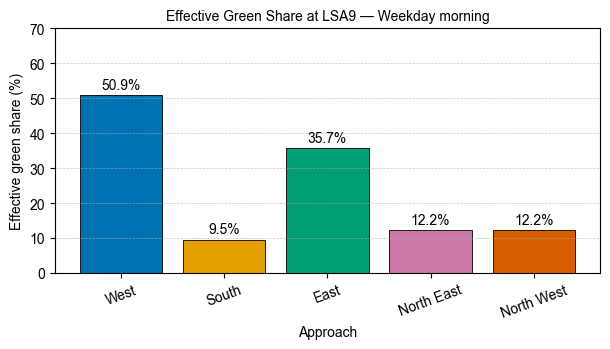

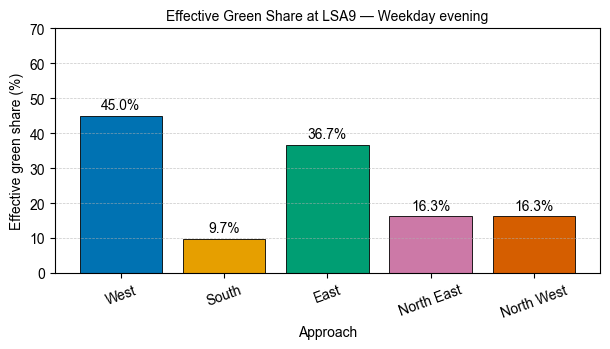

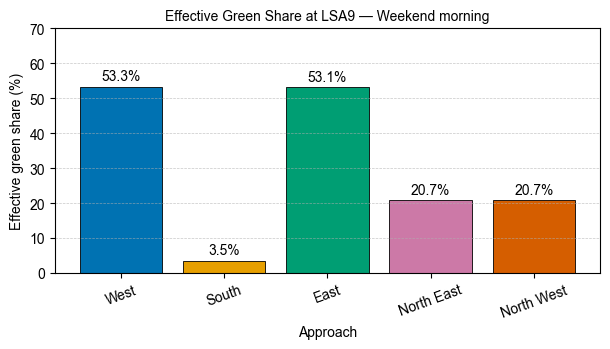

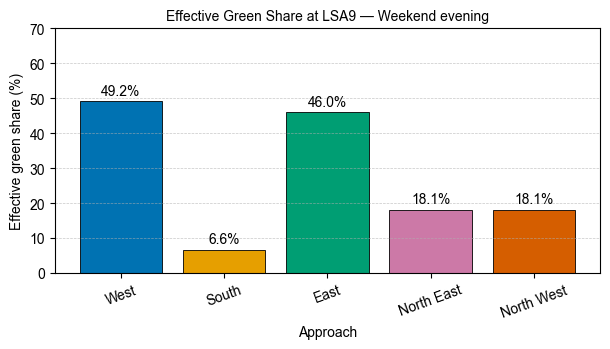

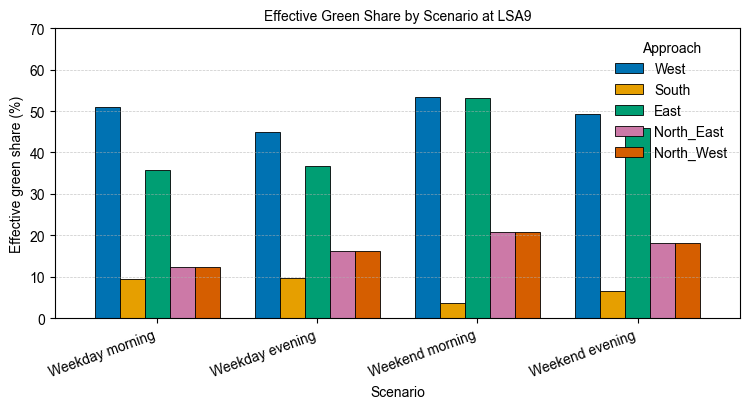

Saved green share figures in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\figures


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 1B: LSA9 GREEN SHARE FIGURES
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)

IN_CSV = BASE_DIR / "LSA9_green_time_summary.csv"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

APPROACH_ORDER = ["West", "South", "East", "North_East", "North_West"]

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

APPROACH_COLORS = {
    "West": "#0072B2",
    "South": "#E69F00",
    "East": "#009E73",
    "North_East": "#CC79A7",
    "North_West": "#D55E00",
}

def clean_label(x):
    return str(x).replace("_", " ")

df = pd.read_csv(IN_CSV)

df["approach"] = df["approach"].astype(str).str.strip()
df["scenario"] = df["scenario"].astype(str).str.strip()

df["approach"] = pd.Categorical(df["approach"], categories=APPROACH_ORDER, ordered=True)
df["scenario"] = pd.Categorical(df["scenario"], categories=SCENARIO_ORDER, ordered=True)

df = df.sort_values(["scenario", "approach"])

for scenario in SCENARIO_ORDER:
    label = SCENARIO_LABELS[scenario]
    temp = df[df["scenario"] == scenario].sort_values("approach")

    fig, ax = plt.subplots(figsize=(6.2, 3.6))

    colors = [APPROACH_COLORS[a] for a in temp["approach"].astype(str)]

    bars = ax.bar(
        [clean_label(a) for a in temp["approach"].astype(str)],
        temp["green_share_percent"],
        color=colors,
        edgecolor="black",
        linewidth=0.6
    )

    ax.set_title(f"Effective Green Share at LSA9 — {label}")
    ax.set_xlabel("Approach")
    ax.set_ylabel("Effective green share (%)")
    ax.set_ylim(0, max(70, temp["green_share_percent"].max() + 10))
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.tick_params(axis="x", rotation=20)

    for bar, value in zip(bars, temp["green_share_percent"]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center", va="bottom")

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA9_green_share_{scenario}.png"
    out_svg = OUT_DIR / f"LSA9_green_share_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

pivot = df.pivot_table(
    index="scenario",
    columns="approach",
    values="green_share_percent",
    aggfunc="mean",
    observed=False
).reindex(SCENARIO_ORDER)

pivot = pivot.reindex(columns=APPROACH_ORDER)

fig, ax = plt.subplots(figsize=(7.6, 4.2))

pivot.plot(
    kind="bar",
    ax=ax,
    width=0.78,
    color=[APPROACH_COLORS[a] for a in pivot.columns],
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Effective Green Share by Scenario at LSA9")
ax.set_xlabel("Scenario")
ax.set_ylabel("Effective green share (%)")
ax.set_ylim(0, max(70, df["green_share_percent"].max() + 10))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

ax.set_xticklabels([SCENARIO_LABELS[s] for s in SCENARIO_ORDER], rotation=20, ha="right")
ax.legend(title="Approach", frameon=False, loc="upper right")

plt.tight_layout()

out_png = OUT_DIR / "LSA9_green_share_grouped_by_scenario.png"
out_svg = OUT_DIR / "LSA9_green_share_grouped_by_scenario.svg"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()

print("Saved green share figures in:")
print(OUT_DIR)

*********
**LSA9 Detector Demand Parser**
This code reads the LSA16 detector JSON files, filters the same representative days/time windows, and calculates the observed demand per approach by summing the assigned detector IDs.

In [3]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 2: LSA9 DETECTOR DEMAND PARSER
# ============================================================

DETECTOR_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA9"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA9_detector_demand_summary.csv"
OUT_XLSX = OUT_DIR / "LSA9_detector_demand_summary.xlsx"


APPROACH_DETECTOR_MAP = {
    "West":       [2, 1],
    "South":      [10],
    "East":       [8, 9],
    "North_East": [4, 5],
    "North_West": [3],
}

SCENARIOS = {
    "weekday_morning": {"date": "2026-03-10", "file": "2026-03-10.json", "start": "08:00:00", "end": "09:00:00"},
    "weekday_evening": {"date": "2026-03-23", "file": "2026-03-23.json", "start": "16:00:00", "end": "17:00:00"},
    "weekend_morning": {"date": "2026-03-14", "file": "2026-03-14.json", "start": "08:00:00", "end": "09:00:00"},
    "weekend_evening": {"date": "2026-03-22", "file": "2026-03-22.json", "start": "16:00:00", "end": "17:00:00"},
}

def extract_count_from_detector(detector):
    reading = detector.get("reading", {})

    if isinstance(reading, dict):
        count_block = reading.get("count", {})

        if isinstance(count_block, dict):
            return count_block.get("value", 0) or 0

        if isinstance(count_block, (int, float)):
            return count_block

    return 0

secondwise_rows = []
summary_rows = []

for scenario_name, scenario in SCENARIOS.items():
    json_path = DETECTOR_DIR / scenario["file"]

    if not json_path.exists():
        print(f"Missing detector file: {json_path}")
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    approach_totals = {approach: 0 for approach in APPROACH_DETECTOR_MAP.keys()}
    approach_measurements = {approach: 0 for approach in APPROACH_DETECTOR_MAP.keys()}

    for timeframe in data.get("timeFrames", []):
        timestamp_str = timeframe.get("timestamp")

        if timestamp_str is None:
            continue

        try:
            timestamp = pd.to_datetime(timestamp_str)
            timestamp_local = timestamp.tz_convert("Europe/Berlin") if timestamp.tzinfo else timestamp

            date_local = str(timestamp_local.date())
            time_local = timestamp_local.time()

            if not (date_local == scenario["date"] and start_t <= time_local < end_t):
                continue

            for detector in timeframe.get("detectors", []):
                det_id = detector.get("id")

                if det_id is None:
                    continue

                count = extract_count_from_detector(detector)

                for approach, detector_ids in APPROACH_DETECTOR_MAP.items():
                    if det_id in detector_ids:
                        approach_totals[approach] += count
                        approach_measurements[approach] += 1

                        secondwise_rows.append({
                            "scenario": scenario_name,
                            "date": scenario["date"],
                            "window_start": scenario["start"],
                            "window_end": scenario["end"],
                            "timestamp_local": str(timestamp_local),
                            "approach": approach,
                            "detector_id": det_id,
                            "count": count,
                        })

        except Exception as e:
            print(f"Skipped timeframe due to error: {e}")
            continue

    for approach, detector_ids in APPROACH_DETECTOR_MAP.items():
        summary_rows.append({
            "scenario": scenario_name,
            "date": scenario["date"],
            "window_start": scenario["start"],
            "window_end": scenario["end"],
            "approach": approach,
            "detector_ids": "+".join(str(x) for x in detector_ids),
            "demand_veh_per_hour": approach_totals[approach],
            "n_detector_measurements": approach_measurements[approach],
        })

demand_summary = pd.DataFrame(summary_rows)
detector_detail = pd.DataFrame(secondwise_rows)

if demand_summary.empty:
    raise ValueError("No detector demand data found. Check detector folder and JSON structure.")

demand_summary = demand_summary.sort_values(["scenario", "approach"])

demand_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    demand_summary.to_excel(writer, sheet_name="Detector_Demand_Summary", index=False)
    detector_detail.to_excel(writer, sheet_name="Detector_Detail", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nDetector demand summary:")
print(demand_summary)

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_detector_demand_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_detector_demand_summary.xlsx

Detector demand summary:
           scenario        date window_start window_end    approach  \
7   weekday_evening  2026-03-23     16:00:00   17:00:00        East   
8   weekday_evening  2026-03-23     16:00:00   17:00:00  North_East   
9   weekday_evening  2026-03-23     16:00:00   17:00:00  North_West   
6   weekday_evening  2026-03-23     16:00:00   17:00:00       South   
5   weekday_evening  2026-03-23     16:00:00   17:00:00        West   
2   weekday_morning  2026-03-10     08:00:00   09:00:00        East   
3   weekday_morning  2026-03-10     08:00:00   09:00:00  North_East   
4   weekday_morning  2026-03-10     08:00:00   09:00:00  North_West   
1   weekday_morning  2026-03-10     08:00:00   09:00:00       South   
0   weekday_morning  202

**************
**LSA9 Capacity and Saturation Calculation**

combines green time (Code 1) + detector demand (Code 2)
calculates: 
 capacity = green_seconds / 2
saturation = demand / capacity

In [4]:
from pathlib import Path
import pandas as pd

# ============================================================
# CODE 3: LSA9 SATURATION CALCULATION
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)

GREEN_FILE = BASE_DIR / "LSA9_green_time_summary.csv"
DEMAND_FILE = BASE_DIR / "LSA9_detector_demand_summary.csv"

OUT_CSV = BASE_DIR / "LSA9_saturation_summary.csv"
OUT_XLSX = BASE_DIR / "LSA9_saturation_summary.xlsx"

green = pd.read_csv(GREEN_FILE)
demand = pd.read_csv(DEMAND_FILE)

df = pd.merge(
    green,
    demand,
    on=["scenario", "date", "window_start", "window_end", "approach"],
    how="inner"
)

df["capacity_veh_per_hour"] = df["green_seconds"] / 2
df["saturation"] = df["demand_veh_per_hour"] / df["capacity_veh_per_hour"]

df["saturation"] = df["saturation"].round(2)
df["capacity_veh_per_hour"] = df["capacity_veh_per_hour"].round(1)

def classify_saturation(x):
    if x < 0.7:
        return "Low"
    elif x < 0.9:
        return "Moderate"
    elif x <= 1.0:
        return "High"
    else:
        return "Over-saturated"

df["saturation_level"] = df["saturation"].apply(classify_saturation)

df = df.sort_values(["scenario", "approach"])

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Saturation_Summary", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nFinal saturation results:")
print(df)

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_saturation_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_saturation_summary.xlsx

Final saturation results:
           scenario        date window_start window_end    approach  \
0   weekday_evening  2026-03-23     16:00:00   17:00:00        East   
1   weekday_evening  2026-03-23     16:00:00   17:00:00  North_East   
2   weekday_evening  2026-03-23     16:00:00   17:00:00  North_West   
3   weekday_evening  2026-03-23     16:00:00   17:00:00       South   
4   weekday_evening  2026-03-23     16:00:00   17:00:00        West   
5   weekday_morning  2026-03-10     08:00:00   09:00:00        East   
6   weekday_morning  2026-03-10     08:00:00   09:00:00  North_East   
7   weekday_morning  2026-03-10     08:00:00   09:00:00  North_West   
8   weekday_morning  2026-03-10     08:00:00   09:00:00       South   
9   weekday_morning  2026-03-10  

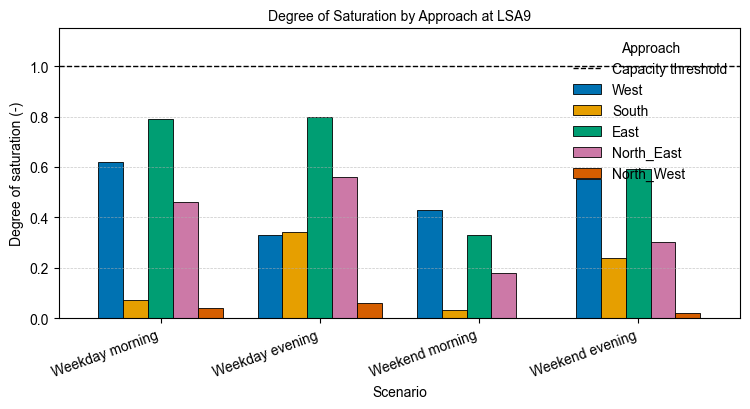

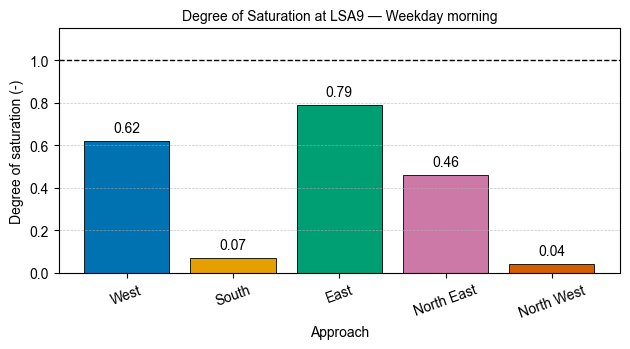

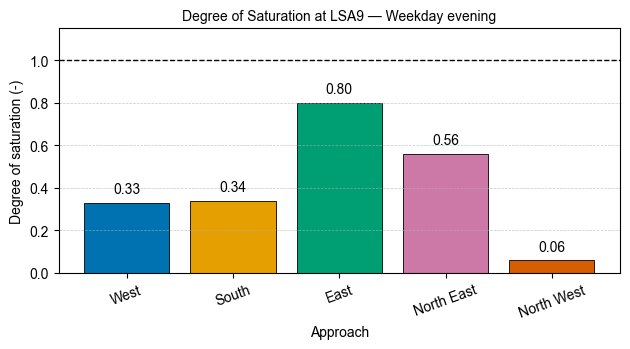

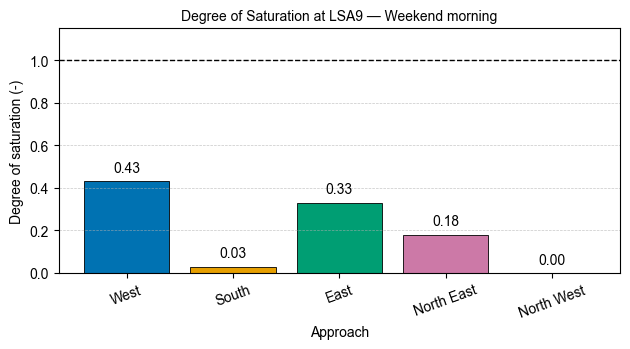

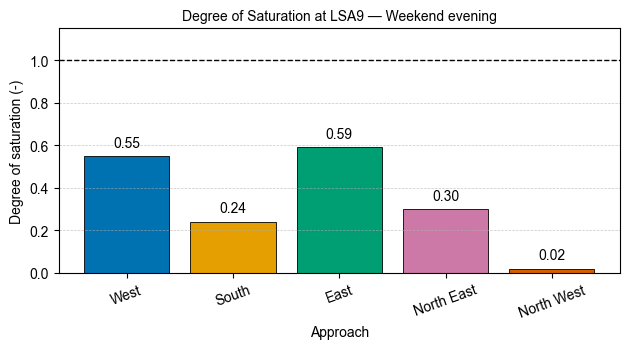

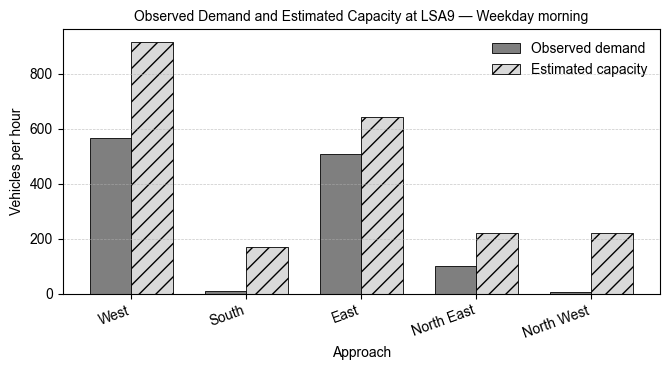

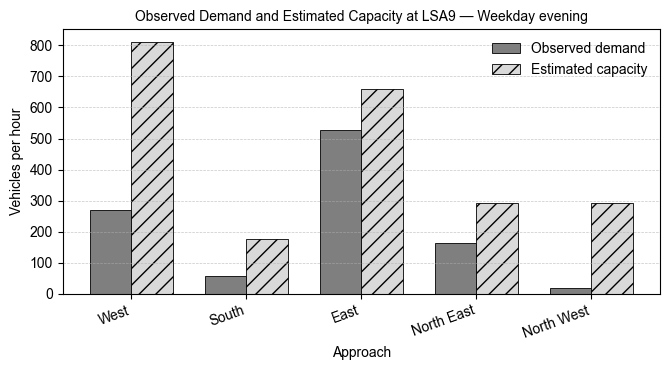

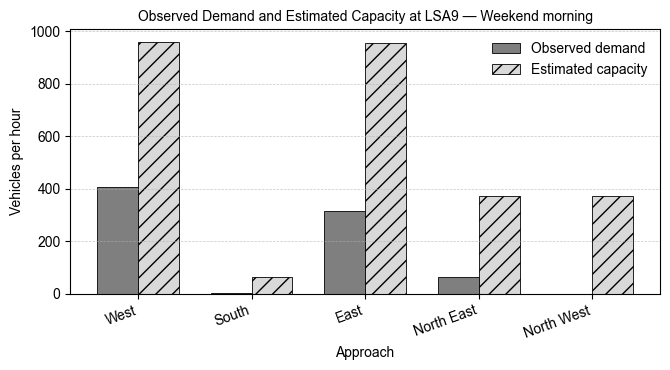

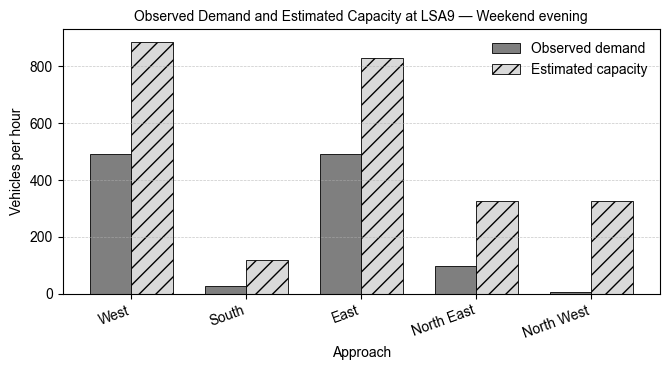

Saved saturation figures in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\figures


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CODE 4: LSA9 SATURATION RESULT FIGURES
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)

IN_CSV = BASE_DIR / "LSA9_saturation_summary.csv"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

APPROACH_ORDER = ["West", "South", "East", "North_East", "North_West"]

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

APPROACH_COLORS = {
    "West": "#0072B2",
    "South": "#E69F00",
    "East": "#009E73",
    "North_East": "#CC79A7",
    "North_West": "#D55E00",
}

def clean_label(x):
    return str(x).replace("_", " ")

df = pd.read_csv(IN_CSV)

df["approach"] = df["approach"].astype(str).str.strip()
df["scenario"] = df["scenario"].astype(str).str.strip()

df["approach"] = pd.Categorical(df["approach"], categories=APPROACH_ORDER, ordered=True)
df["scenario"] = pd.Categorical(df["scenario"], categories=SCENARIO_ORDER, ordered=True)

df = df.sort_values(["scenario", "approach"])

pivot_sat = df.pivot_table(
    index="scenario",
    columns="approach",
    values="saturation",
    aggfunc="mean",
    observed=False
).reindex(SCENARIO_ORDER)

pivot_sat = pivot_sat.reindex(columns=APPROACH_ORDER)

fig, ax = plt.subplots(figsize=(7.6, 4.2))

pivot_sat.plot(
    kind="bar",
    ax=ax,
    width=0.78,
    color=[APPROACH_COLORS[a] for a in pivot_sat.columns],
    edgecolor="black",
    linewidth=0.6
)

ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.0, label="Capacity threshold")

ax.set_title("Degree of Saturation by Approach at LSA9")
ax.set_xlabel("Scenario")
ax.set_ylabel("Degree of saturation (-)")
ax.set_ylim(0, max(1.15, df["saturation"].max() + 0.15))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

ax.set_xticklabels([SCENARIO_LABELS[s] for s in SCENARIO_ORDER], rotation=20, ha="right")
ax.legend(title="Approach", frameon=False, loc="upper right")

plt.tight_layout()

out_png = OUT_DIR / "LSA9_saturation_grouped_bar.png"
out_svg = OUT_DIR / "LSA9_saturation_grouped_bar.svg"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()

for scenario in SCENARIO_ORDER:
    temp = df[df["scenario"] == scenario].sort_values("approach")
    label = SCENARIO_LABELS[scenario]

    fig, ax = plt.subplots(figsize=(6.4, 3.6))

    bars = ax.bar(
        [clean_label(a) for a in temp["approach"].astype(str)],
        temp["saturation"],
        color=[APPROACH_COLORS[a] for a in temp["approach"].astype(str)],
        edgecolor="black",
        linewidth=0.6
    )

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.0)

    ax.set_title(f"Degree of Saturation at LSA9 — {label}")
    ax.set_xlabel("Approach")
    ax.set_ylabel("Degree of saturation (-)")
    ax.set_ylim(0, max(1.15, temp["saturation"].max() + 0.15))
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.tick_params(axis="x", rotation=20)

    for bar, value in zip(bars, temp["saturation"]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.03, f"{value:.2f}", ha="center", va="bottom")

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA9_saturation_{scenario}.png"
    out_svg = OUT_DIR / f"LSA9_saturation_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

for scenario in SCENARIO_ORDER:
    temp = df[df["scenario"] == scenario].sort_values("approach")
    label = SCENARIO_LABELS[scenario]

    x = np.arange(len(temp))
    width = 0.36

    fig, ax = plt.subplots(figsize=(6.8, 3.8))

    ax.bar(
        x - width / 2,
        temp["demand_veh_per_hour"],
        width,
        label="Observed demand",
        color="#7F7F7F",
        edgecolor="black",
        linewidth=0.6
    )

    ax.bar(
        x + width / 2,
        temp["capacity_veh_per_hour"],
        width,
        label="Estimated capacity",
        color="#D9D9D9",
        edgecolor="black",
        linewidth=0.6,
        hatch="//"
    )

    ax.set_title(f"Observed Demand and Estimated Capacity at LSA9 — {label}")
    ax.set_xlabel("Approach")
    ax.set_ylabel("Vehicles per hour")
    ax.set_xticks(x)
    ax.set_xticklabels([clean_label(a) for a in temp["approach"].astype(str)], rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.legend(frameon=False)

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA9_demand_capacity_{scenario}.png"
    out_svg = OUT_DIR / f"LSA9_demand_capacity_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

print("Saved saturation figures in:")
print(OUT_DIR)